In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split

from dataset import APTOSDataset

In [2]:
csv_path = "aptos_dataset/train.csv"
image_dir = "aptos_dataset/train_images"

df = pd.read_csv(csv_path)

In [3]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=78
)

In [29]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
train_dataset = APTOSDataset(train_df, image_dir, transform_train)
val_dataset = APTOSDataset(val_df, image_dir, transform_val)

In [32]:
class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values

print(train_df.shape)
print(val_df.shape)
print(f"Class counts of train set: {class_counts_tr}")
print(f"Class counts of val set: {class_counts_vl}")

(2929, 2)
(733, 2)
Class counts of train set: [1444  296  799  154  236]
Class counts of val set: [361  74 200  39  59]


In [33]:
class_weights = 1. / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler = sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle = False
)

In [35]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels in batch:", labels.unique())

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Unique labels in batch: tensor([0, 1, 2, 3, 4])


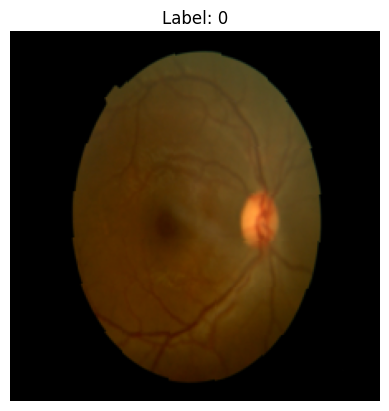

In [36]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img = images[0].cpu().numpy().transpose(1,2,0)

img = std * img + mean
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [ ]:
# WeightedRandomSampler samples the minority classes so in one batch, the class counts are approximately equal

images, labels = next(iter(train_loader))
unique, counts = torch.unique(labels, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0: 6, 1: 5, 2: 7, 3: 7, 4: 7}


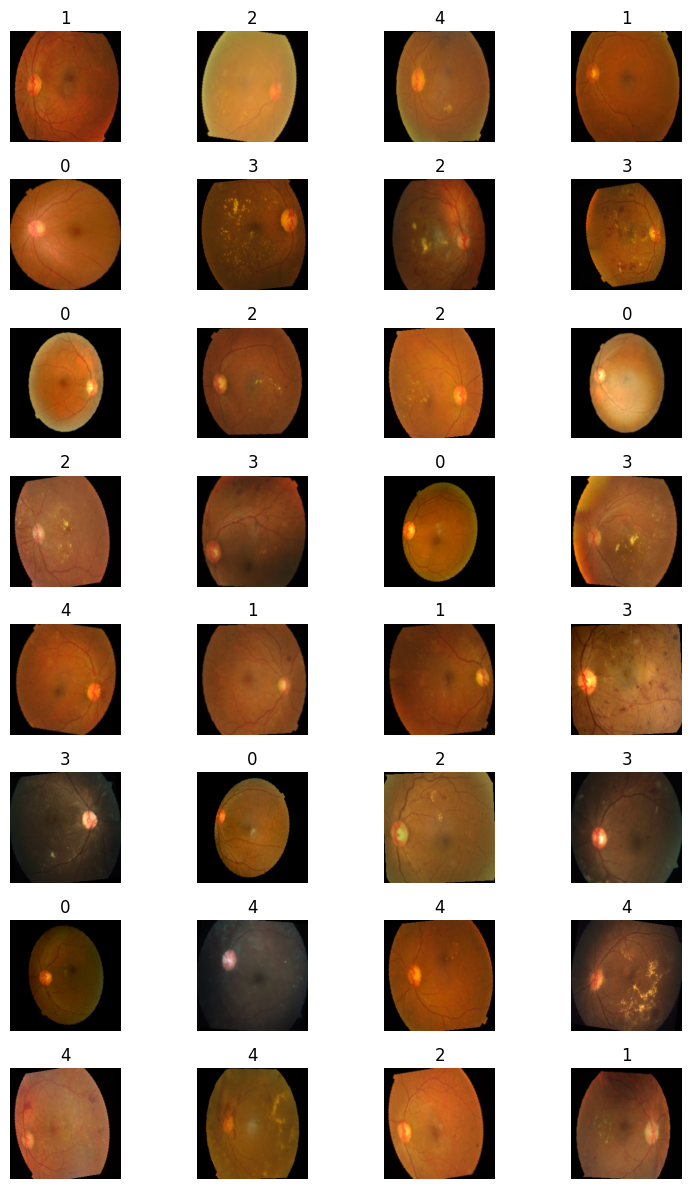

In [ ]:
# visualizing one whole batch, transformations are visible in the images

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

figs, axes = plt.subplots(8,4, figsize=(8,12))
axes = axes.flatten()

for i in range(32):
    img = images[i].cpu().numpy().transpose(1,2,0)

    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')
plt.tight_layout()
plt.show()